<a href="https://colab.research.google.com/github/carlos31255/EV2_ML/blob/main/notebooks/EV2_Spotify_Modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EV2 — Machine Learning 
## Caso C: Predicción de popularidad de canciones en Spotify — Modelamiento

**Estrategia:** clasificación binaria **hit / no-hit** (popularidad ≥ P80 del conjunto de entrenamiento).

### Qué se corrige respecto de la versión anterior de EV2

| # | Problema en la versión anterior | Corrección en este notebook |
|---|---|---|
| 1 | Se conservaban las filas repetidas por `track_id` (una por género): una canción en 4 géneros pesaba 4 veces en el entrenamiento (observación del docente en EP1). | **Una fila por canción** (`track_id`); los géneros pasan a columnas multi-hot. |
| 2 | El `train_test_split` separaba por fila: la misma canción quedaba en train y en test (**fuga de datos**), también dentro de la validación cruzada. | Split y CV **por grupos de canción** (`GroupShuffleSplit`, `StratifiedGroupKFold`). |
| 3 | `track_genre_encoded` (Label Encoding 0-113) mantenía un orden alfabético falso; no escalarlo no lo elimina. | **One-hot** para `key` y `time_signature`, **multi-hot** para género. |
| 4 | El umbral P80 se calculaba con todo el dataset antes del split. | El umbral se calcula **solo con train**. |
| 5 | El StandardScaler se aplicaba fuera de la validación cruzada. | Preprocesamiento dentro de un `Pipeline`: se ajusta **solo con el fold de entrenamiento**. |
| 6 | Gradient Boosting con recall 0.1538 (umbral 0.5 sin balanceo de clases). | `HistGradientBoostingClassifier(class_weight='balanced')`. |

In [13]:
import os
import sys
import joblib
# Soporte para ejecucion directa en Google Colab
if 'google.colab' in sys.modules:
    if not os.path.exists('data/processed/spotify_clean.csv'):
        print("[INFO] Detectado entorno Google Colab. Clonando repositorio...")
        import subprocess
        subprocess.run(['git', 'clone', 'https://github.com/carlos31255/EV2_ML.git'], check=True)
        if os.path.exists('EV2_ML'):
            os.chdir('EV2_ML')

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.model_selection import (train_test_split, GroupShuffleSplit,
                                     StratifiedGroupKFold, cross_validate)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay, f1_score, precision_score,
                             recall_score, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

SPOTIFY_GREEN = '#1DB954'
BG_COLOR, TEXT_COLOR = '#121212', '#FFFFFF'
matplotlib.rcParams.update({
    'figure.dpi': 100, 'axes.facecolor': '#1a1a1a', 'figure.facecolor': BG_COLOR,
    'text.color': TEXT_COLOR, 'axes.labelcolor': TEXT_COLOR, 'xtick.color': TEXT_COLOR,
    'ytick.color': TEXT_COLOR, 'axes.edgecolor': '#333333', 'grid.color': '#333333',
})
SEED = 42
np.random.seed(SEED)
os.makedirs('images', exist_ok=True)
os.makedirs('models', exist_ok=True)
print('[OK] Librerías cargadas. Working directory:', os.getcwd())

[OK] Librerías cargadas. Working directory: c:\Users\Carlos\Desktop\DUOC\Machine Learning\EV2


## 1. Carga del dataset limpio (EV1)

In [14]:
df = pd.read_csv('data/processed/spotify_clean.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (113549, 25)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,liveness,valence,tempo,time_signature,track_genre,speechiness_log,instrumentalness_log,liveness_log,duration_ms_log,track_genre_encoded
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,...,0.358,0.715,87.917,4,acoustic,0.133656,0.000001,0.306013,12.348730,0
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,...,0.101,0.267,77.489,4,acoustic,0.073529,0.000006,0.096219,11.915794,0
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,...,0.117,0.120,76.332,4,acoustic,0.054204,0.000000,0.110647,12.258793,0


## 2. Diagnóstico: canciones repetidas por género

El dataset se armó por género (~1.000 filas por género). Una canción incluida en varios géneros aparece
como varias filas con el mismo `track_id`. Aquí se mide cuánto pesa eso.

In [15]:
n_filas = len(df)
n_canciones = df['track_id'].nunique()
print(f'Filas totales               : {n_filas:,}')
print(f'Canciones únicas (track_id) : {n_canciones:,}')
print(f'Filas "extra" por repetición: {n_filas - n_canciones:,} ({(n_filas - n_canciones)/n_filas*100:.2f}% de las filas)')

# ¿Las filas repetidas son idénticas salvo el género? (popularity y features de audio)
cols_check = [c for c in df.columns if c not in ('track_genre', 'track_genre_encoded')]
variantes = (df.groupby('track_id')[cols_check].nunique(dropna=False) > 1).any(axis=1)
print(f'\ntrack_id cuyas filas difieren en algo más que el género: {variantes.sum():,}')
pop_var = (df.groupby('track_id')['popularity'].nunique() > 1).sum()
print(f'track_id con popularity distinto entre filas            : {pop_var:,}')
dif = df.groupby('track_id')['popularity'].agg(lambda x: x.max() - x.min())
print(f'Diferencia máxima de popularity dentro de un track_id     : {dif.max()} pts | mediana entre los que difieren: {dif[dif > 0].median():.0f} pt')

Filas totales               : 113,549
Canciones únicas (track_id) : 89,740
Filas "extra" por repetición: 23,809 (20.97% de las filas)

track_id cuyas filas difieren en algo más que el género: 720
track_id con popularity distinto entre filas            : 720
Diferencia máxima de popularity dentro de un track_id     : 44 pts | mediana entre los que difieren: 1 pt


N° de géneros por canción -> cantidad de canciones
track_genre
1    73441
2    11424
3     2955
4     1361
5      431
6      104
7       21
8        2
9        1


,canciones,% canciones,filas,% filas
track_genre,,,,
1,73441,81.84,73441,64.68
2,11424,12.73,22848,20.12
3,2955,3.29,8865,7.81
4,1361,1.52,5444,4.79
5,431,0.48,2155,1.90
6,104,0.12,624,0.55
7,21,0.02,147,0.13
8,2,0.00,16,0.01
9,1,0.00,9,0.01


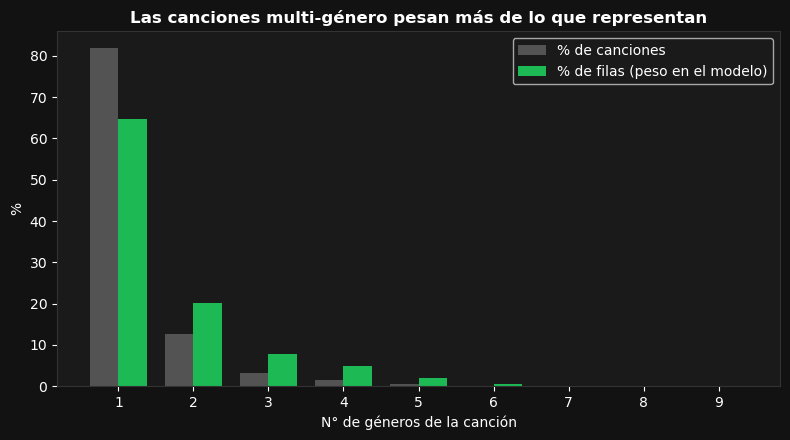

In [16]:
gen_por_cancion = df.groupby('track_id')['track_genre'].nunique()
dist = gen_por_cancion.value_counts().sort_index()
print('N° de géneros por canción -> cantidad de canciones')
print(dist.to_string())

# Peso en el entrenamiento: % de canciones vs % de filas según nº de géneros
filas_por_grupo = dist * dist.index
tabla = pd.DataFrame({
    'canciones': dist,
    '% canciones': (dist / dist.sum() * 100).round(2),
    'filas': filas_por_grupo,
    '% filas': (filas_por_grupo / filas_por_grupo.sum() * 100).round(2),
})
display(tabla)

fig, ax = plt.subplots(figsize=(8, 4.5), facecolor=BG_COLOR)
x = np.arange(len(tabla)); w = 0.38
ax.bar(x - w/2, tabla['% canciones'], w, color='#535353', label='% de canciones')
ax.bar(x + w/2, tabla['% filas'], w, color=SPOTIFY_GREEN, label='% de filas (peso en el modelo)')
ax.set_xticks(x); ax.set_xticklabels(tabla.index)
ax.set_xlabel('N° de géneros de la canción'); ax.set_ylabel('%')
ax.set_title('Las canciones multi-género pesan más de lo que representan', fontweight='bold')
ax.legend(facecolor='#1a1a1a', labelcolor=TEXT_COLOR)
plt.tight_layout()
plt.savefig('images/peso_canciones_multigenero.png', dpi=100, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

### 2.1 Cuantificación de la fuga de datos (comportamiento de la versión anterior)

Se repite **exactamente** el enfoque anterior (mismas variables, Label Encoding del género, umbral 54,
Random Forest) y se cambia **una sola cosa**: cómo se separa train/test.

- **A)** split aleatorio por fila (como en la versión anterior).
- **B)** split por canción (todas las filas de una misma canción quedan en el mismo lado).

La diferencia de AUC es el efecto de la fuga.

In [17]:
df['song_key'] = (df['artists'].str.lower().str.strip() + '||' + df['track_name'].str.lower().str.strip())

FEATS_DEMO = ['danceability', 'energy', 'loudness', 'valence', 'tempo', 'acousticness',
              'speechiness_log', 'instrumentalness_log', 'liveness_log', 'duration_ms_log',
              'explicit', 'mode', 'key', 'time_signature', 'track_genre_encoded']
y_demo = (df['popularity'] >= 54).astype(int)   # umbral fijo de la versión anterior, solo para esta comparación

def rf_demo():
    return RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_leaf=10,
                                  class_weight='balanced', random_state=SEED, n_jobs=-1)

# A) split por fila
tr_a, te_a = train_test_split(df.index, test_size=0.20, random_state=SEED, stratify=y_demo)
m = rf_demo().fit(df.loc[tr_a, FEATS_DEMO], y_demo[tr_a])
auc_a = roc_auc_score(y_demo[te_a], m.predict_proba(df.loc[te_a, FEATS_DEMO])[:, 1])
comparte = df.loc[te_a, 'track_id'].isin(df.loc[tr_a, 'track_id']).mean() * 100

# B) split por canción
tr_b, te_b = next(GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
                  .split(df, y_demo, groups=df['song_key']))
m = rf_demo().fit(df.iloc[tr_b][FEATS_DEMO], y_demo.iloc[tr_b])
auc_b = roc_auc_score(y_demo.iloc[te_b], m.predict_proba(df.iloc[te_b][FEATS_DEMO])[:, 1])

print(f'A) Split por fila     -> AUC test = {auc_a:.4f} | filas de test cuya canción ya estaba en train: {comparte:.1f}%')
print(f'B) Split por canción  -> AUC test = {auc_b:.4f}')
print(f'Inflación por fuga de datos: {auc_a - auc_b:+.4f} de AUC')

A) Split por fila     -> AUC test = 0.7958 | filas de test cuya canción ya estaba en train: 30.8%
B) Split por canción  -> AUC test = 0.7505
Inflación por fuga de datos: +0.0453 de AUC


## 3. Una fila por canción + género multi-hot

- Se conserva **una fila por `track_id`**. Las filas repetidas son idénticas salvo el género y, en una minoría de canciones (ver sección 2), el `popularity`, que difiere levemente entre géneros: en esos casos se usa el **promedio** redondeado.
- Los géneros de cada canción se guardan como columnas 0/1 (`genre_<nombre>`): la información de género
  no se pierde, pero la canción ya no se cuenta varias veces.
- Se crea `song_key` (artista + nombre de pista) para agrupar: una misma canción puede tener **distintos**
  `track_id` (versiones en distintos álbumes) y no debe quedar repartida entre train y test.

In [18]:
generos = df.groupby('track_id')['track_genre'].apply(lambda s: sorted(set(s)))

pop_media = df.groupby('track_id')['popularity'].mean().round().astype(int)
df_song = df.drop_duplicates(subset='track_id').set_index('track_id').drop(
    columns=['track_genre', 'track_genre_encoded'])
df_song['popularity'] = pop_media.loc[df_song.index]   # promedio entre géneros (solo cambia en una minoría de canciones)
mlb = MultiLabelBinarizer()
G = pd.DataFrame(mlb.fit_transform(generos.loc[df_song.index]),
                 columns=[f'genre_{g}' for g in mlb.classes_], index=df_song.index)
df_song = pd.concat([df_song, G], axis=1)
df_song['explicit'] = df_song['explicit'].astype(int)

print(f'Filas antes : {len(df):,}')
print(f'Filas ahora : {len(df_song):,} (una por track_id)')
print(f'Columnas de género (multi-hot): {G.shape[1]}')

# Misma canción con distinto track_id (versiones en otros álbumes)
rep = df_song.duplicated('song_key', keep=False).sum()
print(f'\nFilas que comparten song_key con otro track_id: {rep:,} -> se agrupan al separar train/test')

Filas antes : 113,549
Filas ahora : 89,740 (una por track_id)
Columnas de género (multi-hot): 114

Filas que comparten song_key con otro track_id: 13,281 -> se agrupan al separar train/test


## 4. Separación train / test por canción y variable objetivo

El umbral P80 se calcula **solo con el conjunto de entrenamiento** para que el test no influya en la definición de `hit`.

In [19]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
tr_idx, te_idx = next(gss.split(df_song, groups=df_song['song_key']))
train, test = df_song.iloc[tr_idx].copy(), df_song.iloc[te_idx].copy()

P80 = train['popularity'].quantile(0.80)
train['hit'] = (train['popularity'] >= P80).astype(int)
test['hit']  = (test['popularity']  >= P80).astype(int)

print(f'Umbral P80 (solo train): {P80} pts')
print(f'Train: {len(train):,} canciones | hits: {train["hit"].mean()*100:.1f}%')
print(f'Test : {len(test):,} canciones | hits: {test["hit"].mean()*100:.1f}%')
assert set(train['song_key']).isdisjoint(set(test['song_key'])), 'Hay canciones en ambos conjuntos'
print('[OK] Ninguna canción aparece en train y test a la vez')

Umbral P80 (solo train): 52.0 pts
Train: 71,706 canciones | hits: 21.0%
Test : 18,034 canciones | hits: 20.5%
[OK] Ninguna canción aparece en train y test a la vez


## 5. Preprocesamiento y modelos (Pipeline)

| Variable | Tratamiento |
|---|---|
| Continuas (10) | `StandardScaler` (ajustado solo con train, dentro del Pipeline) |
| `key`, `time_signature` | `OneHotEncoder` (son nominales) |
| `explicit`, `mode` | binarias, sin transformar |
| Género (multi-hot) | columnas 0/1, sin transformar |

In [20]:
FEATURES_SCALE = ['danceability', 'energy', 'loudness', 'valence', 'tempo', 'acousticness',
                  'speechiness_log', 'instrumentalness_log', 'liveness_log', 'duration_ms_log']
FEATURES_CAT   = ['key', 'time_signature']
FEATURES_BIN   = ['explicit', 'mode']
FEATURES_GENRE = [c for c in df_song.columns if c.startswith('genre_')]
ALL_FEATURES   = FEATURES_SCALE + FEATURES_CAT + FEATURES_BIN + FEATURES_GENRE

X_train, y_train, g_train = train[ALL_FEATURES], train['hit'], train['song_key']
X_test,  y_test           = test[ALL_FEATURES],  test['hit']

def make_pre():
    return ColumnTransformer([
        ('num', StandardScaler(), FEATURES_SCALE),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
    ], remainder='passthrough', verbose_feature_names_out=True)

def make_models():
    return {
        'Regresión Logística': Pipeline([('pre', make_pre()),
            ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED))]),
        'Random Forest': Pipeline([('pre', make_pre()),
            ('clf', RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=10,
                                           class_weight='balanced', random_state=SEED, n_jobs=-1))]),
        'Gradient Boosting': Pipeline([('pre', make_pre()),
            ('clf', HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, max_depth=6,
                                                   class_weight='balanced', random_state=SEED))]),
    }

models = make_models()
print(f'Features totales antes de codificar: {len(ALL_FEATURES)} '
      f'({len(FEATURES_SCALE)} continuas, {len(FEATURES_CAT)} nominales, '
      f'{len(FEATURES_BIN)} binarias, {len(FEATURES_GENRE)} de género)')

Features totales antes de codificar: 128 (10 continuas, 2 nominales, 2 binarias, 114 de género)


## 6. Validación cruzada estratificada **por canción** (5-fold)

`StratifiedGroupKFold` con `groups = song_key`: ninguna canción aparece en dos folds distintos.

In [21]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = {}
for name, pipe in models.items():
    print(f'[...] CV {name}')
    r = cross_validate(pipe, X_train, y_train, groups=g_train, cv=cv,
                       scoring=['roc_auc', 'f1', 'precision', 'recall'],
                       return_train_score=True, n_jobs=1)
    cv_rows[name] = {
        'AUC test (CV)':  f"{r['test_roc_auc'].mean():.4f} ± {r['test_roc_auc'].std():.4f}",
        'AUC train (CV)': f"{r['train_roc_auc'].mean():.4f}",
        'Gap AUC':        round(r['train_roc_auc'].mean() - r['test_roc_auc'].mean(), 4),
        'F1 (CV)':        f"{r['test_f1'].mean():.4f} ± {r['test_f1'].std():.4f}",
        'Precision (CV)': f"{r['test_precision'].mean():.4f}",
        'Recall (CV)':    f"{r['test_recall'].mean():.4f}",
    }
cv_table = pd.DataFrame(cv_rows).T
print()
display(cv_table)
print('Criterio: Gap AUC < 0.05 -> sin sobreajuste significativo; >= 0.05 -> sobreajuste a reportar.')

[...] CV Regresión Logística
[...] CV Random Forest
[...] CV Gradient Boosting



,AUC test (CV),AUC train (CV),Gap AUC,F1 (CV),Precision (CV),Recall (CV)
Regresión Logística,0.8380 ± 0.0053,0.8406,0.0026,0.5640 ± 0.0083,0.4342,0.8045
Random Forest,0.8224 ± 0.0055,0.8422,0.0198,0.5373 ± 0.0097,0.4200,0.7463
Gradient Boosting,0.8566 ± 0.0034,0.8847,0.028,0.5677 ± 0.0079,0.4327,0.8253


Criterio: Gap AUC < 0.05 -> sin sobreajuste significativo; >= 0.05 -> sobreajuste a reportar.


## 7. Evaluación final en el conjunto de prueba

In [22]:
results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    results[name] = {
        'model': pipe, 'y_proba': proba, 'y_pred': pred,
        'accuracy': accuracy_score(y_test, pred), 'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred), 'f1': f1_score(y_test, pred),
        'auc': roc_auc_score(y_test, proba),
        'auc_train': roc_auc_score(y_train, pipe.predict_proba(X_train)[:, 1]),
    }

summary = pd.DataFrame({n: {'Accuracy': r['accuracy'], 'Precision': r['precision'], 'Recall': r['recall'],
                            'F1-Score': r['f1'], 'AUC-ROC': r['auc'], 'AUC train': r['auc_train']}
                        for n, r in results.items()}).T.round(4)
print('=== Modelos corregidos — conjunto de prueba (canciones no vistas) ===')
display(summary)

# Comparación con la versión anterior (métricas de esa versión, con fuga y filas repetidas)
prev = {'Regresión Logística': (0.6257, 0.3757, 0.6455),
        'Random Forest':       (0.7981, 0.5117, 0.7384),
        'Gradient Boosting':   (0.8271, 0.2561, 0.1538)}
comp = pd.DataFrame({
    'AUC versión anterior': {n: prev[n][0] for n in prev},
    'AUC corregido':        {n: round(results[n]['auc'], 4) for n in prev},
    'F1 versión anterior':  {n: prev[n][1] for n in prev},
    'F1 corregido':         {n: round(results[n]['f1'], 4) for n in prev},
    'Recall versión anterior': {n: prev[n][2] for n in prev},
    'Recall corregido':        {n: round(results[n]['recall'], 4) for n in prev},
})
comp['Δ AUC'] = (comp['AUC corregido'] - comp['AUC versión anterior']).round(4)
print('\n=== Antes vs. después de las correcciones ===')
display(comp)
print('Nota: la comparación es indicativa. La versión anterior usaba umbral 54, filas repetidas y otro conjunto de test; '
      'aquí el umbral sale del train y el test son canciones no vistas.')

=== Modelos corregidos — conjunto de prueba (canciones no vistas) ===


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,AUC train
Regresión Logística,0.7338,0.4216,0.7979,0.5517,0.8357,0.8404
Random Forest,0.7283,0.4126,0.7631,0.5356,0.8241,0.8403
Gradient Boosting,0.7327,0.4228,0.8271,0.5595,0.8544,0.8812



=== Antes vs. después de las correcciones ===


,AUC versión anterior,AUC corregido,F1 versión anterior,F1 corregido,Recall versión anterior,Recall corregido,Δ AUC
Regresión Logística,0.6257,0.8357,0.3757,0.5517,0.6455,0.7979,0.2100
Random Forest,0.7981,0.8241,0.5117,0.5356,0.7384,0.7631,0.0260
Gradient Boosting,0.8271,0.8544,0.2561,0.5595,0.1538,0.8271,0.0273


Nota: la comparación es indicativa. La versión anterior usaba umbral 54, filas repetidas y otro conjunto de test; aquí el umbral sale del train y el test son canciones no vistas.


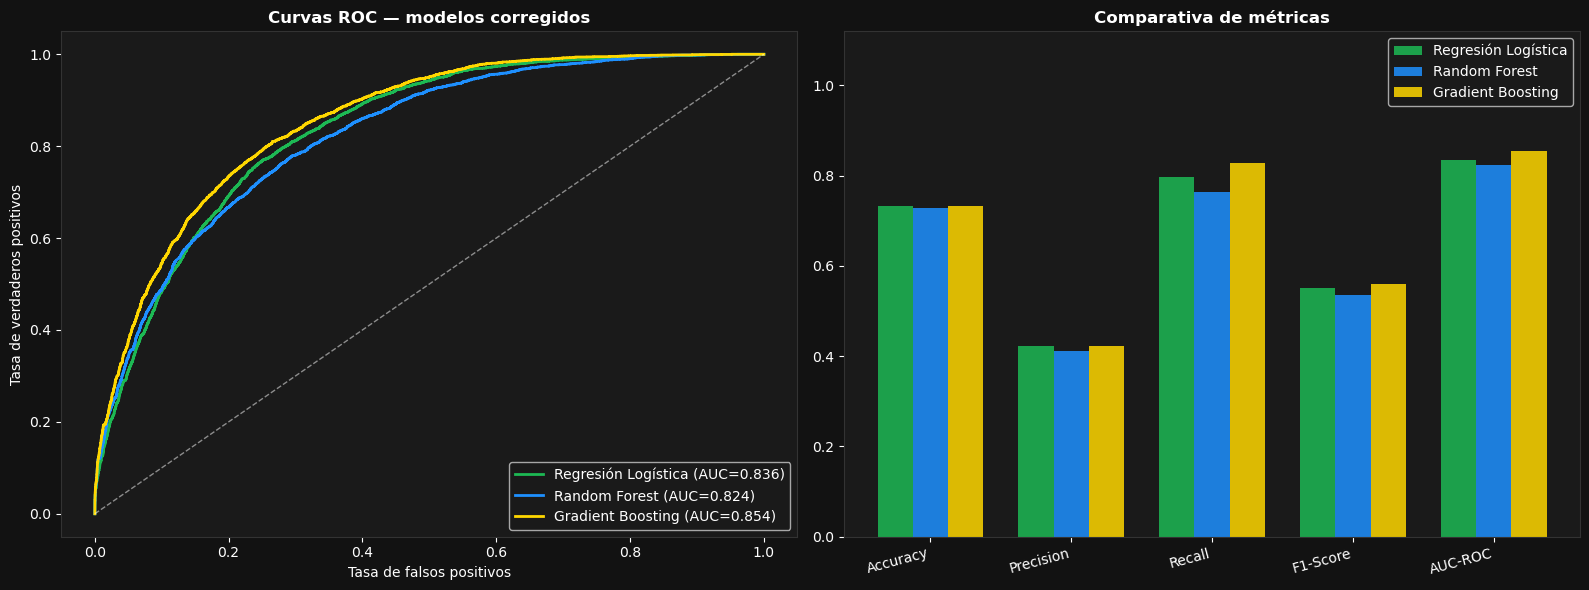

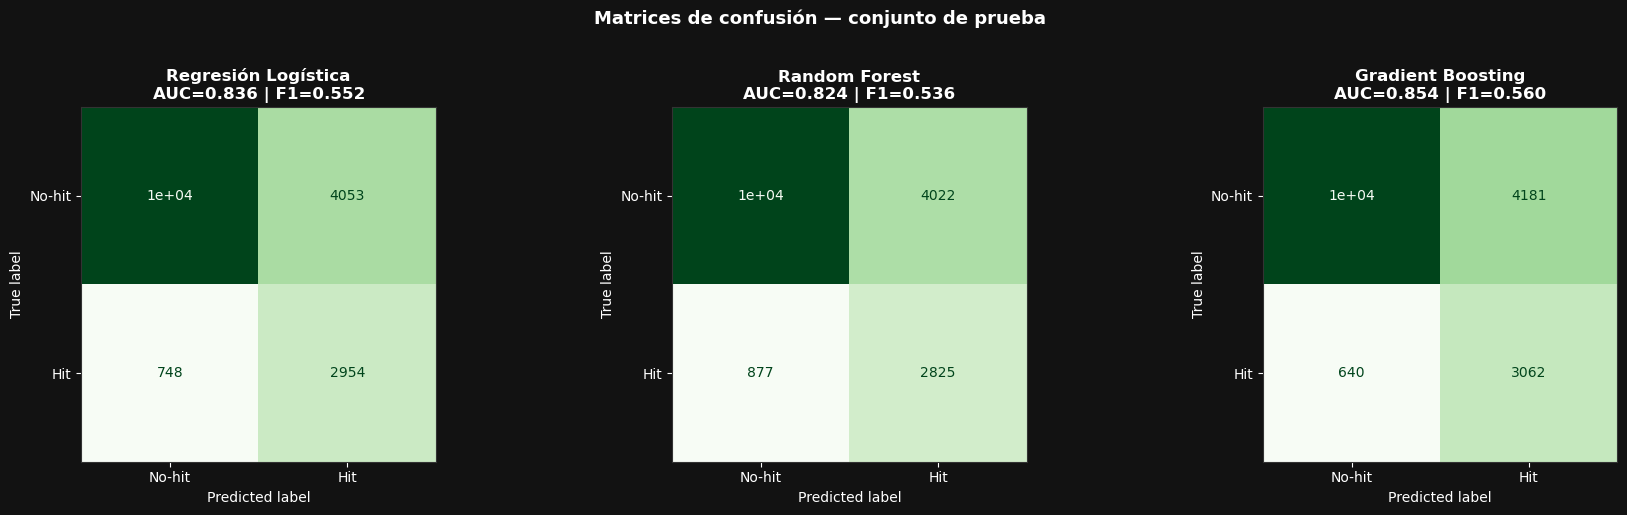

In [23]:
colors = [SPOTIFY_GREEN, '#1E90FF', '#FFD700']
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG_COLOR)

ax1 = axes[0]
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax1.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={r['auc']:.3f})")
ax1.plot([0, 1], [0, 1], 'w--', lw=1, alpha=0.5)
ax1.set_title('Curvas ROC — modelos corregidos', fontweight='bold')
ax1.set_xlabel('Tasa de falsos positivos'); ax1.set_ylabel('Tasa de verdaderos positivos')
ax1.legend(facecolor='#1a1a1a', labelcolor=TEXT_COLOR)

ax2 = axes[1]
metrics_plot = ['accuracy', 'precision', 'recall', 'f1', 'auc']
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metrics_plot)); w = 0.25
for i, (name, r) in enumerate(results.items()):
    ax2.bar(x + i*w, [r[m] for m in metrics_plot], w, label=name, color=colors[i], alpha=0.85)
ax2.set_xticks(x + w); ax2.set_xticklabels(labels, rotation=15, ha='right')
ax2.set_ylim(0, 1.12); ax2.set_title('Comparativa de métricas', fontweight='bold')
ax2.legend(facecolor='#1a1a1a', labelcolor=TEXT_COLOR)
plt.tight_layout()
plt.savefig('images/comparativa_modelos_roc_corregido.png', dpi=100, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG_COLOR)
for ax, (name, r) in zip(axes, results.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, r['y_pred']),
                           display_labels=['No-hit', 'Hit']).plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f"{name}\nAUC={r['auc']:.3f} | F1={r['f1']:.3f}", fontweight='bold')
plt.suptitle('Matrices de confusión — conjunto de prueba', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/matrices_confusion_corregido.png', dpi=100, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

## 8. Importancia de variables (Random Forest)

Las columnas one-hot y multi-hot se suman por variable original para poder interpretarlas.

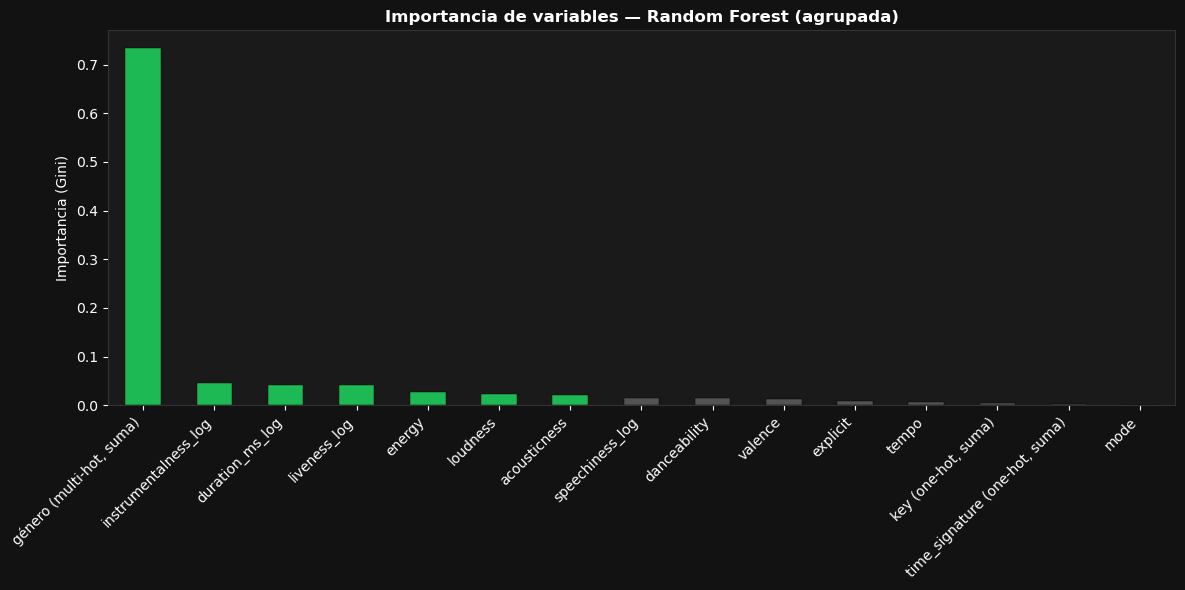

Top 5 variables (agrupadas):
género (multi-hot, suma)    0.7337
instrumentalness_log        0.0451
duration_ms_log             0.0421
liveness_log                0.0420
energy                      0.0262


In [24]:
rf_pipe = results['Random Forest']['model']
names = rf_pipe.named_steps['pre'].get_feature_names_out()
imp = pd.Series(rf_pipe.named_steps['clf'].feature_importances_, index=names)

def agrupar(n):
    if n.startswith('remainder__genre_'):     return 'género (multi-hot, suma)'
    if n.startswith('cat__key_'):             return 'key (one-hot, suma)'
    if n.startswith('cat__time_signature_'):  return 'time_signature (one-hot, suma)'
    return n.split('__', 1)[1]

imp_g = imp.groupby(agrupar).sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG_COLOR)
cols = [SPOTIFY_GREEN if v > imp_g.median() else '#535353' for v in imp_g]
imp_g.plot(kind='bar', ax=ax, color=cols, edgecolor='black', linewidth=0.3)
ax.set_title('Importancia de variables — Random Forest (agrupada)', fontweight='bold')
ax.set_ylabel('Importancia (Gini)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/feature_importance_rf_corregido.png', dpi=100, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print('Top 5 variables (agrupadas):')
print(imp_g.head(5).round(4).to_string())

## 9. Resumen automático de resultados

In [25]:
mejor = max(results, key=lambda n: results[n]['auc'])
print(f"Mejor modelo por AUC-ROC en test (métrica principal): {mejor} (AUC = {results[mejor]['auc']:.4f}, "
      f"F1 = {results[mejor]['f1']:.4f}, recall = {results[mejor]['recall']:.4f})")
print()
for n in results:
    gap_cv = cv_table.loc[n, 'Gap AUC']
    estado = 'sin sobreajuste significativo' if gap_cv < 0.05 else 'SOBREAJUSTE (gap >= 0.05)'
    print(f"{n:<22} gap AUC (CV) = {gap_cv:.4f} -> {estado}")

Mejor modelo por AUC-ROC en test (métrica principal): Gradient Boosting (AUC = 0.8544, F1 = 0.5595, recall = 0.8271)

Regresión Logística    gap AUC (CV) = 0.0026 -> sin sobreajuste significativo
Random Forest          gap AUC (CV) = 0.0198 -> sin sobreajuste significativo
Gradient Boosting      gap AUC (CV) = 0.0280 -> sin sobreajuste significativo


## 10. Serialización y guardado de modelos entrenados (models/)

Se guardan los pipelines completos (preprocesamiento + clasificador) en la carpeta `models/` utilizando `joblib`.
Esto permite cargar cualquier modelo en producción o futuras evaluaciones con un solo comando, recibiendo los datos crudos sin riesgo de data leakage.

In [ ]:
import joblib
import os

os.makedirs('models', exist_ok=True)

# Mapeo de nombres limpios para serialización
filename_map = {
    'regresi': 'models/logistic_regression.joblib',
    'random forest': 'models/random_forest.joblib',
    'gradient': 'models/gradient_boosting.joblib'
}

print('=== Guardando modelos en carpeta models/ ===')
for name, data in results.items():
    pipe = data['model']
    target_path = None
    for key, path in filename_map.items():
        if key in name.lower():
            target_path = path
            break
    if target_path is None:
        safe_name = ''.join(ch if ch.isalnum() else '_' for ch in name.lower())
        target_path = f'models/{safe_name}.joblib'
    
    joblib.dump(pipe, target_path)
    size_mb = os.path.getsize(target_path) / (1024 * 1024)
    print(f'[OK] {name:<25} -> {target_path} ({size_mb:.2f} MB)')

# Guardar copia explícita del mejor modelo seleccionado
best_path = 'models/best_model.joblib'
if 'mejor' in locals() and mejor in results:
    joblib.dump(results[mejor]['model'], best_path)
    print(f'[OK] Mejor modelo ({mejor}) guardado como {best_path}')

# Verificación de carga y predicción con datos nuevos
loaded_pipe = joblib.load(best_path)
sample_pred = loaded_pipe.predict(X_test.iloc[:3])
print(f'[OK] Verificación de carga exitosa. Predicciones muestra: {sample_pred}')


## 11. Conclusiones

- **Duplicados por género:** se pasó de una fila por (canción, género) a **una fila por canción**, con el género como
  columnas multi-hot. Ya no hay canciones que pesen más solo por pertenecer a más géneros.
- **Fuga de datos:** la separación train/test y la validación cruzada se hacen **por canción** (`song_key`). La sección 2.1
  cuantifica cuánto inflaba las métricas el split por fila.
- **Codificación:** el género y las variables nominales (`key`, `time_signature`) ya no llevan un orden numérico falso.
- **Umbral y escalado:** el P80 y el `StandardScaler` se calculan solo con datos de entrenamiento (dentro del Pipeline en la CV).
- **Elección del modelo:** se decide con la métrica principal declarada (AUC-ROC) y se reporta el gap train-test de la
  validación cruzada; la tabla de la sección 7 muestra el efecto de cada corrección frente a la versión anterior.
- **Uso ético:** el modelo es una herramienta de apoyo a decisiones de inversión, no un filtro automático, para no
  retroalimentar el sesgo de popularidad acumulada ya identificado en EV1.